Q-Training Model (Revised)
- stateless Q-learning
- stronger convergence definition
- continuous + grid benchmark comparison
- steady-state average learned weights
- convergence speed (cumulative reward gap)
- hyperparameter and random-seed experiments

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import deque
from itertools import product

In [46]:
# =========================================================
# 1. LOAD DATA
# =========================================================

outdir = Path("project3_outputs")

mu_hat = np.load(outdir / "mu_hat.npy")
Sigma_hat = np.load(outdir / "Sigma_hat.npy")

Sigma_df = pd.read_csv(outdir / "covariance_matrix.csv", index_col=0)
asset_names = list(Sigma_df.columns)

# bounded action grid exported from optimalBenchmark.ipynb
action_file = outdir / "bounded_feasible_weights.csv"
weights_df = pd.read_csv(action_file)
action_grid = weights_df[["w1", "w2", "w3"]].values.astype(float)

# optional continuous bounded benchmark
continuous_benchmark_path = outdir / "bounded_benchmark_weights.csv"
continuous_benchmark_weights = None
if continuous_benchmark_path.exists():
    cont_df = pd.read_csv(continuous_benchmark_path)
    continuous_benchmark_weights = cont_df["weight"].values.astype(float)

print("Assets:", asset_names)
print("mu_hat:", mu_hat)
print("Sigma_hat:\n", Sigma_hat)
print("Action file:", action_file)
print("Number of feasible actions:", len(action_grid))
print(weights_df.head())

if continuous_benchmark_weights is not None:
    print("Continuous benchmark weights:", continuous_benchmark_weights)

Assets: ['SPY', 'IEF', 'GLD']
mu_hat: [ 0.00051575 -0.00024641  0.00032329]
Sigma_hat:
 [[1.08500755e-04 5.42930040e-06 1.54645268e-05]
 [5.42930040e-06 2.63825810e-05 1.88849140e-05]
 [1.54645268e-05 1.88849140e-05 8.14528009e-05]]
Action file: project3_outputs/bounded_feasible_weights.csv
Number of feasible actions: 306
    w1   w2   w3
0 -0.5 -0.0  1.5
1 -0.5  0.1  1.4
2 -0.5  0.2  1.3
3 -0.5  0.3  1.2
4 -0.5  0.4  1.1
Continuous benchmark weights: [ 0.98354359 -0.5         0.51645641]


In [47]:
# =========================================================
# 2. REWARD + ENVIRONMENT
# =========================================================

def portfolio_return(weights, asset_returns):
    w = np.asarray(weights, dtype=float)
    r = np.asarray(asset_returns, dtype=float)

    if w.ndim != 1 or r.ndim != 1:
        raise ValueError("weights and asset_returns must both be 1D arrays")
    if w.shape[0] != r.shape[0]:
        raise ValueError("weights and asset_returns must have the same length")
    if not np.isfinite(w).all() or not np.isfinite(r).all():
        raise ValueError("weights and asset_returns must contain only finite values")

    return float(np.dot(w, r))


def reward_from_portfolio_return(portfolio_ret, gamma):
    if gamma < 0:
        raise ValueError("gamma must be non-negative")
    rp = float(portfolio_ret)
    return float(rp - 0.5 * gamma * (rp ** 2))


def mean_variance_reward(weights, asset_returns, gamma):
    rp = portfolio_return(weights, asset_returns)
    return reward_from_portfolio_return(rp, gamma)


def sample_one_return(mu, Sigma, rng):
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)
    return rng.multivariate_normal(mean=mu, cov=Sigma)

In [48]:
# =========================================================
# 3. BENCHMARKS
# =========================================================

def utility_from_moments(weights, mu, Sigma, gamma):
    w = np.asarray(weights, dtype=float)
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)

    mean_ = float(w @ mu)
    var_ = float(w @ Sigma @ w)
    utility_ = float(mean_ - 0.5 * gamma * var_)
    return {
        "mean": mean_,
        "variance": var_,
        "utility": utility_,
    }


def best_grid_benchmark(action_grid, mu, Sigma, gamma):
    utilities = []
    for w in action_grid:
        u = utility_from_moments(w, mu, Sigma, gamma)["utility"]
        utilities.append(u)

    utilities = np.array(utilities)
    idx = int(np.argmax(utilities))

    return {
        "best_idx": idx,
        "best_weights": action_grid[idx],
        "best_utility": float(utilities[idx]),
        "all_utilities": utilities,
    }


def build_benchmark_bundle(action_grid, mu, Sigma, gamma, continuous_weights=None):
    grid_bench = best_grid_benchmark(action_grid, mu, Sigma, gamma)

    bundle = {
        "grid_idx": grid_bench["best_idx"],
        "grid_weights": grid_bench["best_weights"],
        "grid_stats": utility_from_moments(grid_bench["best_weights"], mu, Sigma, gamma),
    }

    if continuous_weights is not None:
        bundle["continuous_weights"] = continuous_weights
        bundle["continuous_stats"] = utility_from_moments(continuous_weights, mu, Sigma, gamma)
    else:
        bundle["continuous_weights"] = None
        bundle["continuous_stats"] = None

    return bundle

In [49]:
# =========================================================
# 4. Q-LEARNING
# =========================================================

def epsilon_greedy_action(Q, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(len(Q)))
    return int(np.argmax(Q))


def compute_recent_average_weights(weight_history, window):
    if len(weight_history) < window:
        return None
    arr = np.asarray(weight_history[-window:], dtype=float)
    return arr.mean(axis=0)


def train_q_learning(
        mu,
        Sigma,
        action_grid,
        gamma=3.0,
        alpha=0.05,
        beta=0.001,
        discount=0.95,
        max_iter=50000,
        convergence_window=2000,   # kept only for compatibility
        q_tol=1e-6,                # kept only for compatibility
        weight_tol=5e-3,
        benchmark_tol=0.15,        # kept only for compatibility
        grid_benchmark_weights=None,
        seed=42,
        verbose=False
):
    """
    Stateless Q-learning:
        Q(a_t) <- Q(a_t) + alpha * [reward + discount * max_a' Q(a') - Q(a_t)]

    Stricter convergence rule:
    the model is considered converged only if the Euclidean distance
    between consecutive chosen portfolio weights remains sufficiently small
    for a sustained number of periods.

    Specifically, convergence requires:
        || w_t - w_{t-1} ||_2 < weight_tol
    for the last `stable_periods` consecutive iterations.
    """
    rng = np.random.default_rng(seed)

    n_actions = len(action_grid)
    Q = np.zeros(n_actions, dtype=float)

    reward_history = []
    epsilon_history = []
    action_history = []
    best_action_history = []
    q_max_history = []
    q_change_history = []
    chosen_weight_history = []

    converged = False
    convergence_iter = None
    convergence_details = {}

    prev_w = None
    recent_weight_distances = []

    # stricter setting: require stability over multiple consecutive iterations
    stable_periods = 50
    min_iter_before_check = 5000

    for t in range(1, max_iter + 1):
        epsilon = float(np.exp(-beta * t))
        old_Q = Q.copy()

        a_idx = epsilon_greedy_action(Q, epsilon, rng)
        w = action_grid[a_idx]

        r_next = sample_one_return(mu, Sigma, rng)
        reward = mean_variance_reward(w, r_next, gamma)

        td_target = reward + discount * np.max(Q)
        td_error = td_target - Q[a_idx]
        Q[a_idx] = Q[a_idx] + alpha * td_error

        current_best_idx = int(np.argmax(Q))
        q_change = float(np.max(np.abs(Q - old_Q)))

        reward_history.append(reward)
        epsilon_history.append(epsilon)
        action_history.append(a_idx)
        best_action_history.append(current_best_idx)
        q_max_history.append(float(np.max(Q)))
        q_change_history.append(q_change)
        chosen_weight_history.append(w.copy())

        if prev_w is not None:
            weight_distance = float(np.linalg.norm(w - prev_w))
            recent_weight_distances.append(weight_distance)

            if len(recent_weight_distances) > stable_periods:
                recent_weight_distances.pop(0)

            if t >= min_iter_before_check and len(recent_weight_distances) == stable_periods:
                all_small = all(d < weight_tol for d in recent_weight_distances)

                if all_small:
                    converged = True
                    convergence_iter = t
                    convergence_details = {
                        "definition": f"euclidean distance between consecutive weights remains below tolerance for {stable_periods} consecutive iterations",
                        "stable_periods": stable_periods,
                        "recent_weight_distances": recent_weight_distances.copy(),
                        "max_recent_distance": max(recent_weight_distances),
                        "weight_tol": weight_tol,
                        "current_weights": w.copy(),
                        "previous_weights": prev_w.copy(),
                        # keep compatibility fields
                        "formal_converged": converged,
                        "practical_converged": converged,
                        "best_action_stable": np.nan,
                        "q_changes_small": np.nan,
                        "weight_stable": converged,
                        "most_common_action_share": np.nan,
                        "q_small_share": np.nan,
                        "benchmark_distance": np.nan,
                        "recent_avg_weights": None,
                        "prev_avg_weights": None,
                    }

                    if verbose:
                        print(f"Converged at iteration {t}")
                        print(f"Stable periods required: {stable_periods}")
                        print(f"Recent distances: {recent_weight_distances}")
                        print(f"Max recent distance: {max(recent_weight_distances)}")
                        print(f"Tolerance: {weight_tol}")
                    break

        prev_w = w.copy()

    if not converged:
        convergence_iter = max_iter
        convergence_details = {
            "definition": f"euclidean distance between consecutive weights remains below tolerance for {stable_periods} consecutive iterations",
            "stable_periods": stable_periods,
            "recent_weight_distances": recent_weight_distances.copy(),
            "max_recent_distance": max(recent_weight_distances) if len(recent_weight_distances) > 0 else np.nan,
            "weight_tol": weight_tol,
            "current_weights": chosen_weight_history[-1].copy() if len(chosen_weight_history) > 0 else None,
            "previous_weights": chosen_weight_history[-2].copy() if len(chosen_weight_history) > 1 else None,
            # keep compatibility fields
            "formal_converged": False,
            "practical_converged": False,
            "best_action_stable": np.nan,
            "q_changes_small": np.nan,
            "weight_stable": False,
            "most_common_action_share": np.nan,
            "q_small_share": np.nan,
            "benchmark_distance": np.nan,
            "recent_avg_weights": None,
            "prev_avg_weights": None,
        }

        if verbose:
            print("Did not meet stricter convergence rule before max_iter.")
            print(f"Using final iteration = {max_iter}")

    best_action_idx = int(np.argmax(Q))
    best_weights = action_grid[best_action_idx]

    return {
        "Q": Q,
        "best_action_idx": best_action_idx,
        "best_weights": best_weights,
        "reward_history": np.array(reward_history),
        "epsilon_history": np.array(epsilon_history),
        "action_history": np.array(action_history),
        "best_action_history": np.array(best_action_history),
        "q_max_history": np.array(q_max_history),
        "q_change_history": np.array(q_change_history),
        "chosen_weight_history": np.asarray(chosen_weight_history),
        "converged": converged,
        "convergence_iter": convergence_iter,
        "convergence_details": convergence_details,
        "params": {
            "gamma": gamma,
            "alpha": alpha,
            "beta": beta,
            "discount": discount,
            "max_iter": max_iter,
            "convergence_window": convergence_window,
            "q_tol": q_tol,
            "weight_tol": weight_tol,
            "seed": seed,
        },
    }

In [50]:
# =========================================================
# 5. TRAINING-PATH AVERAGE WEIGHTS + FIXED-POLICY EVALUATION
# =========================================================

def average_learned_weights_from_training(train_result, window=None):
    """
    Compute average learned weights directly from the realized training path.

    This is closer to the project requirement
        wbar_QL = (1/T) * sum_t w_t^{QL}
    than simply repeating the final best action.
    """
    weight_history = np.asarray(train_result["chosen_weight_history"], dtype=float)

    if weight_history.ndim != 2 or len(weight_history) == 0:
        raise ValueError("chosen_weight_history is empty or malformed")

    if window is not None:
        if window <= 0:
            raise ValueError("window must be positive")
        window = min(window, len(weight_history))
        weight_history = weight_history[-window:]

    return weight_history.mean(axis=0)


def fixed_policy_evaluation(
        learned_weights,
        mu,
        Sigma,
        gamma,
        T=5000,
        seed=999
):
    """
    Evaluate a fixed portfolio policy after training.

    This is a supplementary diagnostic.
    The main 'average learned weights' comparison should come
    from average_learned_weights_from_training(...).
    """
    rng = np.random.default_rng(seed)

    weights_path = []
    rewards = []
    returns = []

    learned_weights = np.asarray(learned_weights, dtype=float)

    for _ in range(T):
        r_next = sample_one_return(mu, Sigma, rng)
        rp = portfolio_return(learned_weights, r_next)
        rw = reward_from_portfolio_return(rp, gamma)

        weights_path.append(learned_weights.copy())
        returns.append(rp)
        rewards.append(rw)

    weights_path = np.asarray(weights_path)
    returns = np.asarray(returns)
    rewards = np.asarray(rewards)

    return {
        "avg_fixed_policy_weights": weights_path.mean(axis=0),
        "mean_portfolio_return": float(returns.mean()),
        "var_portfolio_return": float(returns.var(ddof=1)),
        "mean_reward": float(rewards.mean()),
        "weights_path": weights_path,
        "returns": returns,
        "rewards": rewards,
    }

In [51]:
# =========================================================
# 6. CONVERGENCE SPEED / SAME-PATH COMPARISON
# =========================================================

def compare_policies_on_same_path(
        learned_weights,
        grid_benchmark_weights,
        mu,
        Sigma,
        gamma,
        T=5000,
        seed=2025,
        continuous_benchmark_weights=None
):
    """
    Compare learned policy and benchmark policies on the same simulated path.
    """
    rng = np.random.default_rng(seed)

    learned_rewards = []
    grid_rewards = []
    cont_rewards = [] if continuous_benchmark_weights is not None else None

    learned_weights = np.asarray(learned_weights, dtype=float)
    grid_benchmark_weights = np.asarray(grid_benchmark_weights, dtype=float)
    if continuous_benchmark_weights is not None:
        continuous_benchmark_weights = np.asarray(continuous_benchmark_weights, dtype=float)

    for _ in range(T):
        r_next = sample_one_return(mu, Sigma, rng)

        rp_learned = portfolio_return(learned_weights, r_next)
        rp_grid = portfolio_return(grid_benchmark_weights, r_next)

        learned_rewards.append(reward_from_portfolio_return(rp_learned, gamma))
        grid_rewards.append(reward_from_portfolio_return(rp_grid, gamma))

        if continuous_benchmark_weights is not None:
            rp_cont = portfolio_return(continuous_benchmark_weights, r_next)
            cont_rewards.append(reward_from_portfolio_return(rp_cont, gamma))

    learned_rewards = np.asarray(learned_rewards)
    grid_rewards = np.asarray(grid_rewards)

    out = {
        "learned_rewards": learned_rewards,
        "grid_rewards": grid_rewards,
        "grid_reward_gap": grid_rewards - learned_rewards,
        "cum_grid_reward_gap": np.cumsum(grid_rewards - learned_rewards),
        "mean_grid_reward_gap": float(np.mean(grid_rewards - learned_rewards)),
    }

    if continuous_benchmark_weights is not None:
        cont_rewards = np.asarray(cont_rewards)
        out["continuous_rewards"] = cont_rewards
        out["continuous_reward_gap"] = cont_rewards - learned_rewards
        out["cum_continuous_reward_gap"] = np.cumsum(cont_rewards - learned_rewards)
        out["mean_continuous_reward_gap"] = float(np.mean(cont_rewards - learned_rewards))

    return out

In [52]:
# =========================================================
# 7. HYPERPARAMETER + SEED EXPERIMENTS
# =========================================================

def run_hyperparameter_seed_experiments(
        mu,
        Sigma,
        action_grid,
        gamma,
        alpha_list,
        beta_list,
        discount_list,
        seed_list,
        max_iter=50000,
        convergence_window=2000,
        q_tol=1e-10,
        weight_tol=1e-4,
        continuous_weights=None,
):
    benchmarks = build_benchmark_bundle(
        action_grid=action_grid,
        mu=mu,
        Sigma=Sigma,
        gamma=gamma,
        continuous_weights=continuous_weights,
    )

    rows = []
    detailed_runs = []

    total_runs = len(alpha_list) * len(beta_list) * len(discount_list) * len(seed_list)
    run_counter = 0

    for alpha, beta, discount, seed in product(alpha_list, beta_list, discount_list, seed_list):
        run_counter += 1
        print(f"Running {run_counter}/{total_runs} | alpha={alpha}, beta={beta}, discount={discount}, seed={seed}")

        result = train_q_learning(
            mu=mu,
            Sigma=Sigma,
            action_grid=action_grid,
            gamma=gamma,
            alpha=alpha,
            beta=beta,
            discount=discount,
            max_iter=max_iter,
            convergence_window=convergence_window,
            q_tol=q_tol,
            weight_tol=weight_tol,
            benchmark_tol=0.15,
            grid_benchmark_weights=benchmarks["grid_weights"],
            seed=seed,
            verbose=False,
        )

        learned_weights = result["best_weights"]
        avg_training_weights = average_learned_weights_from_training(
            result,
            window=min(convergence_window, len(result["chosen_weight_history"]))
        )

        learned_stats = utility_from_moments(learned_weights, mu, Sigma, gamma)
        avg_training_stats = utility_from_moments(avg_training_weights, mu, Sigma, gamma)

        distance_to_grid = float(np.linalg.norm(learned_weights - benchmarks["grid_weights"]))
        distance_avg_training_to_grid = float(np.linalg.norm(avg_training_weights - benchmarks["grid_weights"]))

        utility_gap_to_grid = float(benchmarks["grid_stats"]["utility"] - learned_stats["utility"])
        utility_gap_avg_training_to_grid = float(
            benchmarks["grid_stats"]["utility"] - avg_training_stats["utility"]
        )

        if benchmarks["continuous_weights"] is not None:
            distance_to_cont = float(np.linalg.norm(learned_weights - benchmarks["continuous_weights"]))
            distance_avg_training_to_cont = float(
                np.linalg.norm(avg_training_weights - benchmarks["continuous_weights"])
            )

            utility_gap_to_cont = float(benchmarks["continuous_stats"]["utility"] - learned_stats["utility"])
            utility_gap_avg_training_to_cont = float(
                benchmarks["continuous_stats"]["utility"] - avg_training_stats["utility"]
            )
        else:
            distance_to_cont = np.nan
            distance_avg_training_to_cont = np.nan
            utility_gap_to_cont = np.nan
            utility_gap_avg_training_to_cont = np.nan

        row = {
            "alpha": alpha,
            "beta": beta,
            "discount": discount,
            "seed": seed,
            "converged": result["converged"],
            "convergence_iter": result["convergence_iter"],
            "best_action_idx": result["best_action_idx"],
            "w1": learned_weights[0],
            "w2": learned_weights[1],
            "w3": learned_weights[2],
            "avg_train_w1": avg_training_weights[0],
            "avg_train_w2": avg_training_weights[1],
            "avg_train_w3": avg_training_weights[2],
            "distance_to_grid_benchmark": distance_to_grid,
            "distance_to_continuous_benchmark": distance_to_cont,
            "distance_avg_training_to_grid": distance_avg_training_to_grid,
            "distance_avg_training_to_continuous": distance_avg_training_to_cont,
            "learned_mean": learned_stats["mean"],
            "learned_variance": learned_stats["variance"],
            "learned_utility": learned_stats["utility"],
            "grid_benchmark_utility": benchmarks["grid_stats"]["utility"],
            "utility_gap_to_grid": utility_gap_to_grid,
            "utility_gap_to_continuous": utility_gap_to_cont,
            "utility_gap_avg_training_to_grid": utility_gap_avg_training_to_grid,
            "utility_gap_avg_training_to_continuous": utility_gap_avg_training_to_cont,
            "grid_w1": benchmarks["grid_weights"][0],
            "grid_w2": benchmarks["grid_weights"][1],
            "grid_w3": benchmarks["grid_weights"][2],
        }

        rows.append(row)

        detailed_runs.append({
            "config": {
                "alpha": alpha,
                "beta": beta,
                "discount": discount,
                "seed": seed,
            },
            "result": result,
        })

    results_df = pd.DataFrame(rows)
    return results_df, detailed_runs, benchmarks

In [53]:
# =========================================================
# 8. CONFIG
# =========================================================

gamma = 3.0

# finer search grid
alpha_list = [0.005, 0.01, 0.02, 0.05]
beta_list = [0.0005, 0.001, 0.002]
discount_list = [0.90]

seed_list = [123]

max_iter = 300000
convergence_window = 2000
q_tol = 1e-6
weight_tol = 5e-3
steady_state_T = 5000
same_path_T = 5000


In [54]:
# =========================================================
# 9. RUN EXPERIMENTS
# =========================================================

results_df, detailed_runs, benchmarks = run_hyperparameter_seed_experiments(
    mu=mu_hat,
    Sigma=Sigma_hat,
    action_grid=action_grid,
    gamma=gamma,
    alpha_list=alpha_list,
    beta_list=beta_list,
    discount_list=discount_list,
    seed_list=seed_list,
    max_iter=max_iter,
    convergence_window=convergence_window,
    q_tol=q_tol,
    weight_tol=weight_tol,
    continuous_weights=continuous_benchmark_weights,
)

print("\n===== Benchmarks =====")
print("Grid benchmark weights:", benchmarks["grid_weights"])
print("Grid benchmark utility:", benchmarks["grid_stats"]["utility"])
if benchmarks["continuous_weights"] is not None:
    print("Continuous benchmark weights:", benchmarks["continuous_weights"])
    print("Continuous benchmark utility:", benchmarks["continuous_stats"]["utility"])

Running 1/12 | alpha=0.005, beta=0.0005, discount=0.9, seed=123
Running 2/12 | alpha=0.005, beta=0.001, discount=0.9, seed=123
Running 3/12 | alpha=0.005, beta=0.002, discount=0.9, seed=123
Running 4/12 | alpha=0.01, beta=0.0005, discount=0.9, seed=123
Running 5/12 | alpha=0.01, beta=0.001, discount=0.9, seed=123
Running 6/12 | alpha=0.01, beta=0.002, discount=0.9, seed=123
Running 7/12 | alpha=0.02, beta=0.0005, discount=0.9, seed=123
Running 8/12 | alpha=0.02, beta=0.001, discount=0.9, seed=123
Running 9/12 | alpha=0.02, beta=0.002, discount=0.9, seed=123
Running 10/12 | alpha=0.05, beta=0.0005, discount=0.9, seed=123
Running 11/12 | alpha=0.05, beta=0.001, discount=0.9, seed=123
Running 12/12 | alpha=0.05, beta=0.002, discount=0.9, seed=123

===== Benchmarks =====
Grid benchmark weights: [ 1.  -0.5  0.5]
Grid benchmark utility: 0.000596518511394103
Continuous benchmark weights: [ 0.98354359 -0.5         0.51645641]
Continuous benchmark utility: 0.0005965831103702292


In [55]:
# =========================================================
# 10. SAVE RESULTS
# =========================================================

results_path = outdir / "q_learning_hyperparameter_seed_results.csv"
results_df.to_csv(results_path, index=False)

print("Saved results to:", results_path)
print(results_df.head())

Saved results to: project3_outputs/q_learning_hyperparameter_seed_results.csv
   alpha    beta  discount  seed  converged  convergence_iter  \
0  0.005  0.0005       0.9   123       True              5828   
1  0.005  0.0010       0.9   123       True              5068   
2  0.005  0.0020       0.9   123       True              5000   
3  0.010  0.0005       0.9   123       True              5828   
4  0.010  0.0010       0.9   123       True              5068   

   best_action_idx   w1   w2   w3  ...  learned_variance  learned_utility  \
0              224  0.7  0.3  0.0  ...          0.000058         0.000200   
1              259  1.0 -0.1  0.1  ...          0.000111         0.000406   
2              131  0.2 -0.5  1.3  ...          0.000131         0.000450   
3              289  1.3 -0.1 -0.2  ...          0.000178         0.000363   
4              230  0.8 -0.5  0.7  ...          0.000116         0.000589   

   grid_benchmark_utility  utility_gap_to_grid  utility_gap_to_conti

In [56]:
# =========================================================
# 11. BEST RUNS
# =========================================================

best_by_distance = results_df.sort_values(
    by=[
        "converged",
        "distance_avg_training_to_grid",
        "utility_gap_avg_training_to_grid",
        "convergence_iter"
    ],
    ascending=[False, True, True, True]
).reset_index(drop=True)

print("===== Top 10 runs by distance to grid benchmark =====")
print(best_by_distance.head(10))

===== Top 10 runs by distance to grid benchmark =====
   alpha    beta  discount  seed  converged  convergence_iter  \
0  0.010  0.0010       0.9   123       True              5068   
1  0.020  0.0010       0.9   123       True              5068   
2  0.020  0.0005       0.9   123       True              5828   
3  0.050  0.0005       0.9   123       True              5828   
4  0.005  0.0010       0.9   123       True              5068   
5  0.050  0.0010       0.9   123       True              5068   
6  0.050  0.0020       0.9   123       True              5000   
7  0.010  0.0005       0.9   123       True              5828   
8  0.020  0.0020       0.9   123       True              5000   
9  0.005  0.0005       0.9   123       True              5828   

   best_action_idx   w1   w2   w3  ...  learned_variance  learned_utility  \
0              230  0.8 -0.5  0.7  ...          0.000116         0.000589   
1              257  1.0 -0.3  0.3  ...          0.000121         0.000505   

In [57]:
# =========================================================
# 12. SUMMARY BY HYPERPARAMS
# =========================================================

summary_by_hyperparams = (
    results_df.groupby(["alpha", "beta", "discount"])
    .agg(
        n_runs=("seed", "count"),
        n_converged=("converged", "sum"),
        avg_convergence_iter=("convergence_iter", "mean"),
        avg_distance_to_grid=("distance_to_grid_benchmark", "mean"),
        avg_distance_avg_training_to_grid=("distance_avg_training_to_grid", "mean"),
        min_distance_avg_training_to_grid=("distance_avg_training_to_grid", "min"),
        avg_distance_to_continuous=("distance_to_continuous_benchmark", "mean"),
        avg_distance_avg_training_to_continuous=("distance_avg_training_to_continuous", "mean"),
        avg_utility_gap_grid=("utility_gap_to_grid", "mean"),
        avg_utility_gap_avg_training_grid=("utility_gap_avg_training_to_grid", "mean"),
        min_utility_gap_avg_training_grid=("utility_gap_avg_training_to_grid", "min"),
    )
    .reset_index()
    .sort_values(
        by=["n_converged", "avg_distance_avg_training_to_grid", "avg_utility_gap_avg_training_grid"],
        ascending=[False, True, True]
    )
)

print("===== Summary by hyperparameter setting =====")
print(summary_by_hyperparams)

===== Summary by hyperparameter setting =====
    alpha    beta  discount  n_runs  n_converged  avg_convergence_iter  \
4   0.010  0.0010       0.9       1            1                5068.0   
7   0.020  0.0010       0.9       1            1                5068.0   
6   0.020  0.0005       0.9       1            1                5828.0   
9   0.050  0.0005       0.9       1            1                5828.0   
1   0.005  0.0010       0.9       1            1                5068.0   
10  0.050  0.0010       0.9       1            1                5068.0   
11  0.050  0.0020       0.9       1            1                5000.0   
3   0.010  0.0005       0.9       1            1                5828.0   
8   0.020  0.0020       0.9       1            1                5000.0   
0   0.005  0.0005       0.9       1            1                5828.0   
2   0.005  0.0020       0.9       1            1                5000.0   
5   0.010  0.0020       0.9       1            1                50

In [58]:
# =========================================================
# 13. BEST SINGLE RUN
# =========================================================

best_row = best_by_distance.iloc[0]
print("===== Best Single Run =====")
for col in best_row.index:
    print(f"{col}: {best_row[col]}")

===== Best Single Run =====
alpha: 0.01
beta: 0.001
discount: 0.9
seed: 123
converged: True
convergence_iter: 5068
best_action_idx: 230
w1: 0.8
w2: -0.5
w3: 0.7
avg_train_w1: 0.7886499999999723
avg_train_w2: -0.4821
avg_train_w3: 0.6934500000000252
distance_to_grid_benchmark: 0.28284271247461895
distance_to_continuous_benchmark: 0.25956983055799326
distance_avg_training_to_grid: 0.2870751382478487
distance_avg_training_to_continuous: 0.26387620274432383
learned_mean: 0.0007621053115000061
learned_variance: 0.00011570539104914492
learned_utility: 0.0005885472249262888
grid_benchmark_utility: 0.000596518511394103
utility_gap_to_grid: 7.971286467814268e-06
utility_gap_to_continuous: 8.035885443940377e-06
utility_gap_avg_training_to_grid: 1.621078308387705e-05
utility_gap_avg_training_to_continuous: 1.6275382060003158e-05
grid_w1: 1.0
grid_w2: -0.5
grid_w3: 0.5


In [59]:
# =========================================================
# 14. GET BEST RUN DETAIL
# =========================================================

best_alpha = best_row["alpha"]
best_beta = best_row["beta"]
best_discount = best_row["discount"]
best_seed = best_row["seed"]

best_run_detail = None
for item in detailed_runs:
    cfg = item["config"]
    if (
            cfg["alpha"] == best_alpha
            and cfg["beta"] == best_beta
            and cfg["discount"] == best_discount
            and cfg["seed"] == best_seed
    ):
        best_run_detail = item
        break

if best_run_detail is None:
    raise RuntimeError("Could not locate the detailed best run.")

best_result = best_run_detail["result"]
print("Best run learned weights:", best_result["best_weights"])
print("Best run convergence iteration:", best_result["convergence_iter"])
print("Best run converged:", best_result["converged"])
print("Convergence details:", best_result["convergence_details"])

Best run learned weights: [ 0.8 -0.5  0.7]
Best run convergence iteration: 5068
Best run converged: True
Convergence details: {'definition': 'euclidean distance between consecutive weights remains below tolerance for 50 consecutive iterations', 'stable_periods': 50, 'recent_weight_distances': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'max_recent_distance': 0.0, 'weight_tol': 0.005, 'current_weights': array([ 0.8, -0.5,  0.7]), 'previous_weights': array([ 0.8, -0.5,  0.7]), 'formal_converged': True, 'practical_converged': True, 'best_action_stable': nan, 'q_changes_small': nan, 'weight_stable': True, 'most_common_action_share': nan, 'q_small_share': nan, 'benchmark_distance': nan, 'recent_avg_weights': None, 'prev_avg_weights': None}


In [60]:
# =========================================================
# 15. AVERAGE LEARNED WEIGHTS + FIXED-POLICY DIAGNOSTIC
# =========================================================

avg_learned_weights = average_learned_weights_from_training(
    best_result,
    window=min(convergence_window, len(best_result["chosen_weight_history"]))
)

fixed_policy_eval = fixed_policy_evaluation(
    learned_weights=best_result["best_weights"],
    mu=mu_hat,
    Sigma=Sigma_hat,
    gamma=gamma,
    T=steady_state_T,
    seed=999,
)

print("===== Average Learned Weights from Training Path =====")
print("Average learned weights (training path):", avg_learned_weights)

avg_training_stats = utility_from_moments(avg_learned_weights, mu_hat, Sigma_hat, gamma)
print("Avg-training-path mean:", avg_training_stats["mean"])
print("Avg-training-path variance:", avg_training_stats["variance"])
print("Avg-training-path utility:", avg_training_stats["utility"])

dist_avg_to_grid = np.linalg.norm(avg_learned_weights - benchmarks["grid_weights"])
print("Distance(avg learned training path, grid benchmark):", dist_avg_to_grid)

if benchmarks["continuous_weights"] is not None:
    dist_avg_to_cont = np.linalg.norm(avg_learned_weights - benchmarks["continuous_weights"])
    print("Distance(avg learned training path, continuous benchmark):", dist_avg_to_cont)

print("\n===== Fixed-Policy Diagnostic =====")
print("Fixed policy weights:", best_result["best_weights"])
print("Fixed-policy mean portfolio return:", fixed_policy_eval["mean_portfolio_return"])
print("Fixed-policy variance of portfolio return:", fixed_policy_eval["var_portfolio_return"])
print("Fixed-policy mean reward:", fixed_policy_eval["mean_reward"])

===== Average Learned Weights from Training Path =====
Average learned weights (training path): [ 0.78865 -0.4821   0.69345]
Avg-training-path mean: 0.0007497232892190461
Avg-training-path variance: 0.00011294370727254671
Avg-training-path utility: 0.000580307728310226
Distance(avg learned training path, grid benchmark): 0.2870751382478487
Distance(avg learned training path, continuous benchmark): 0.26387620274432383

===== Fixed-Policy Diagnostic =====
Fixed policy weights: [ 0.8 -0.5  0.7]
Fixed-policy mean portfolio return: 0.0007140667138127169
Fixed-policy variance of portfolio return: 0.00011208165558611481
Fixed-policy mean reward: 0.0005452130180225577


# Extra Credit

In [61]:
# =========================================================
# 16. CONVERGENCE SPEED / SAME-PATH COMPARISON
# =========================================================

speed_eval = compare_policies_on_same_path(
    learned_weights=avg_learned_weights,
    grid_benchmark_weights=benchmarks["grid_weights"],
    continuous_benchmark_weights=benchmarks["continuous_weights"],
    mu=mu_hat,
    Sigma=Sigma_hat,
    gamma=gamma,
    T=same_path_T,
    seed=2025,
)

print("===== Convergence Speed / Reward Gap =====")
print("Mean reward gap vs grid benchmark:", speed_eval["mean_grid_reward_gap"])
print("Final cumulative reward gap vs grid benchmark:", speed_eval["cum_grid_reward_gap"][-1])

if "mean_continuous_reward_gap" in speed_eval:
    print("Mean reward gap vs continuous benchmark:", speed_eval["mean_continuous_reward_gap"])
    print("Final cumulative reward gap vs continuous benchmark:", speed_eval["cum_continuous_reward_gap"][-1])

===== Convergence Speed / Reward Gap =====
Mean reward gap vs grid benchmark: 2.7164355067731232e-05
Final cumulative reward gap vs grid benchmark: 0.13582177533865608
Mean reward gap vs continuous benchmark: 2.6258636077183117e-05
Final cumulative reward gap vs continuous benchmark: 0.1312931803859153


In [62]:
# =========================================================
# 17. PLOTTING FUNCTIONS
# =========================================================

def plot_training_results(train_result, rolling_window=200):
    reward_history = train_result["reward_history"]
    epsilon_history = train_result["epsilon_history"]
    best_action_history = train_result["best_action_history"]
    q_max_history = train_result["q_max_history"]

    if len(reward_history) >= rolling_window:
        rolling_reward = np.convolve(
            reward_history,
            np.ones(rolling_window) / rolling_window,
            mode="valid"
        )
    else:
        rolling_reward = reward_history

    plt.figure(figsize=(8, 4))
    plt.plot(rolling_reward)
    plt.title("Rolling Average Reward")
    plt.xlabel("Iteration")
    plt.ylabel("Reward")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epsilon_history)
    plt.title("Epsilon Decay")
    plt.xlabel("Iteration")
    plt.ylabel("Epsilon")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(best_action_history)
    plt.title("Best Action Index Over Time")
    plt.xlabel("Iteration")
    plt.ylabel("Best Action Index")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(q_max_history)
    plt.title("Max Q-value Over Time")
    plt.xlabel("Iteration")
    plt.ylabel("Max Q")
    plt.tight_layout()
    plt.show()


def plot_weight_comparison(avg_learned_weights, grid_weights, asset_names, continuous_weights=None):
    x = np.arange(len(avg_learned_weights))
    width = 0.25

    plt.figure(figsize=(8, 4))

    if continuous_weights is not None:
        plt.bar(x - width, continuous_weights, width=width, label="Continuous Benchmark")
        plt.bar(x, grid_weights, width=width, label="Grid Benchmark")
        plt.bar(x + width, avg_learned_weights, width=width, label="Avg Learned Weights")
    else:
        plt.bar(x - width / 2, grid_weights, width=width, label="Grid Benchmark")
        plt.bar(x + width / 2, avg_learned_weights, width=width, label="Avg Learned Weights")

    plt.xticks(x, asset_names)
    plt.ylabel("Weight")
    plt.title("Average Learned Weights vs Benchmarks")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_cumulative_reward_gaps(speed_eval):
    plt.figure(figsize=(8, 4))
    plt.plot(speed_eval["cum_grid_reward_gap"], label="Grid Benchmark - Learned")
    if "cum_continuous_reward_gap" in speed_eval:
        plt.plot(speed_eval["cum_continuous_reward_gap"], label="Continuous Benchmark - Learned")
    plt.title("Cumulative Reward Gap")
    plt.xlabel("Period")
    plt.ylabel("Cumulative Reward Difference")
    plt.legend()
    plt.tight_layout()
    plt.show()

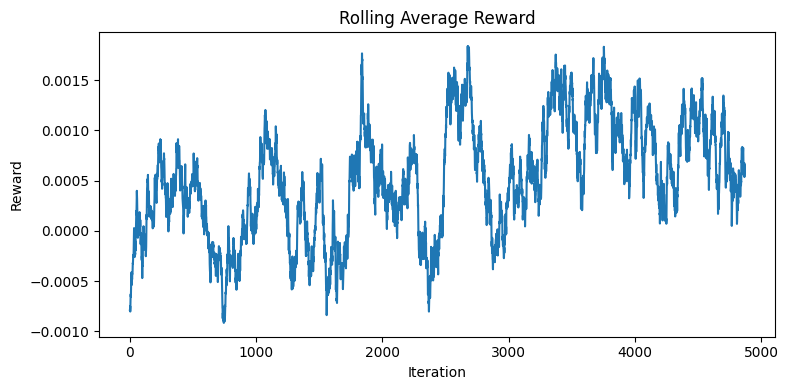

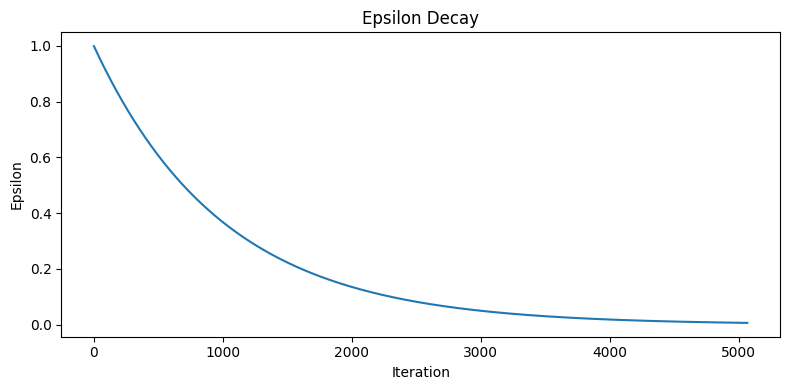

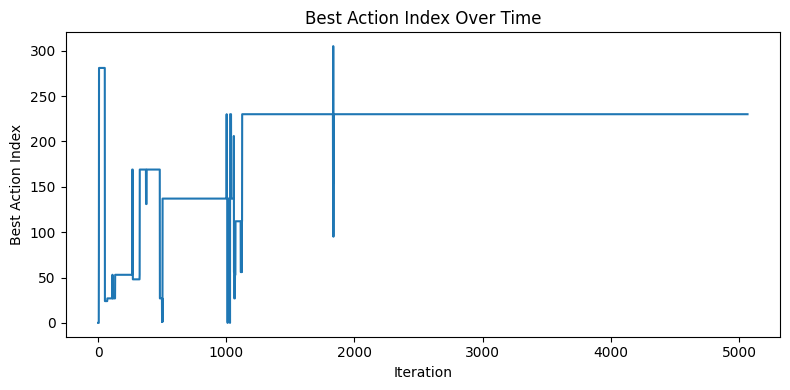

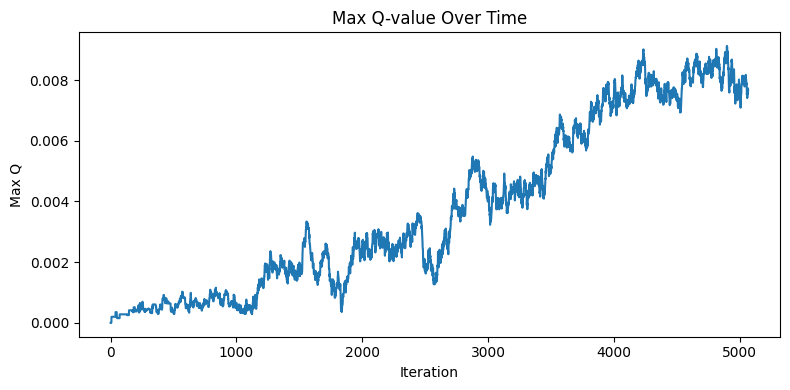

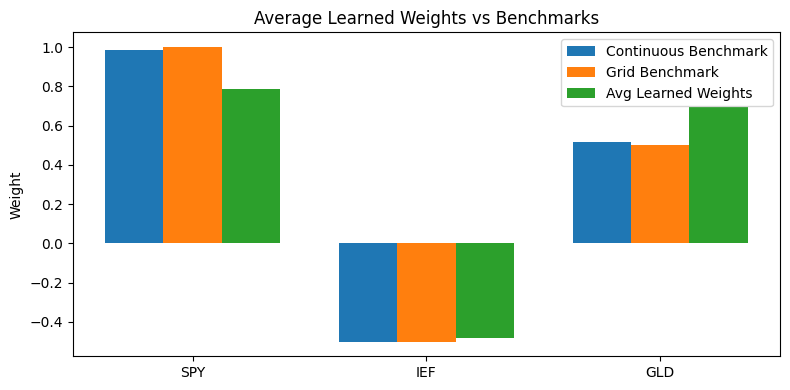

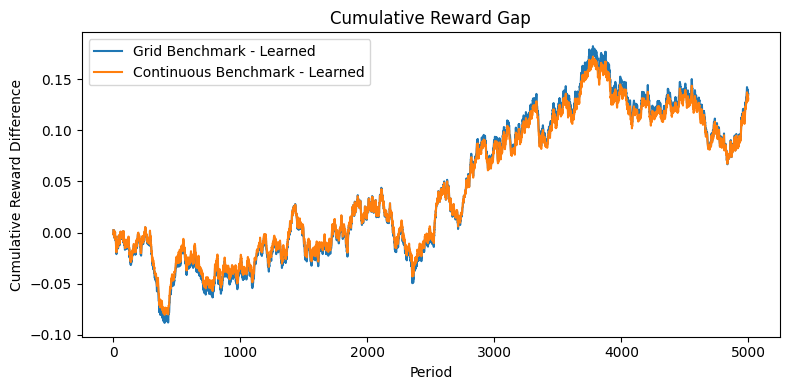

In [63]:
# =========================================================
# 18. PLOTS
# =========================================================

plot_training_results(best_result, rolling_window=200)

plot_weight_comparison(
    avg_learned_weights=avg_learned_weights,
    grid_weights=benchmarks["grid_weights"],
    continuous_weights=benchmarks["continuous_weights"],
    asset_names=asset_names,
)

plot_cumulative_reward_gaps(speed_eval)

In [64]:
# =========================================================
# 19. SEED STABILITY FOR ONE HYPERPARAM SET
# =========================================================

inspect_alpha = 0.05
inspect_beta = 0.001
inspect_discount = 0.95

subset = results_df[
    (results_df["alpha"] == inspect_alpha) &
    (results_df["beta"] == inspect_beta) &
    (results_df["discount"] == inspect_discount)
    ].copy()

subset = subset.sort_values("seed").reset_index(drop=True)

print("===== Stability across seeds =====")
print(subset[[
    "alpha", "beta", "discount", "seed",
    "converged", "convergence_iter",
    "w1", "w2", "w3",
    "avg_train_w1", "avg_train_w2", "avg_train_w3",
    "distance_to_grid_benchmark",
    "distance_avg_training_to_grid",
    "distance_to_continuous_benchmark",
    "distance_avg_training_to_continuous",
    "utility_gap_to_grid",
    "utility_gap_avg_training_to_grid",
]])

===== Stability across seeds =====
Empty DataFrame
Columns: [alpha, beta, discount, seed, converged, convergence_iter, w1, w2, w3, avg_train_w1, avg_train_w2, avg_train_w3, distance_to_grid_benchmark, distance_avg_training_to_grid, distance_to_continuous_benchmark, distance_avg_training_to_continuous, utility_gap_to_grid, utility_gap_avg_training_to_grid]
Index: []


In [65]:
# =========================================================
# 20. SAVE A CLEAN PRESENTATION TABLE
# =========================================================

presentation_table = pd.DataFrame({
    "metric": [
        "avg learned(training path) w1", "avg learned(training path) w2", "avg learned(training path) w3",
        "fixed policy w1", "fixed policy w2", "fixed policy w3",
        "grid benchmark w1", "grid benchmark w2", "grid benchmark w3",
        "distance avg learned(training path) to grid",
        "mean reward gap vs grid",
        "final cumulative reward gap vs grid"
    ],
    "value": [
        avg_learned_weights[0], avg_learned_weights[1], avg_learned_weights[2],
        best_result["best_weights"][0], best_result["best_weights"][1], best_result["best_weights"][2],
        benchmarks["grid_weights"][0], benchmarks["grid_weights"][1], benchmarks["grid_weights"][2],
        dist_avg_to_grid,
        speed_eval["mean_grid_reward_gap"],
        speed_eval["cum_grid_reward_gap"][-1],
    ]
})

if benchmarks["continuous_weights"] is not None:
    extra = pd.DataFrame({
        "metric": [
            "continuous benchmark w1", "continuous benchmark w2", "continuous benchmark w3",
            "distance avg learned(training path) to continuous",
            "mean reward gap vs continuous",
            "final cumulative reward gap vs continuous"
        ],
        "value": [
            benchmarks["continuous_weights"][0],
            benchmarks["continuous_weights"][1],
            benchmarks["continuous_weights"][2],
            dist_avg_to_cont,
            speed_eval["mean_continuous_reward_gap"],
            speed_eval["cum_continuous_reward_gap"][-1],
        ]
    })
    presentation_table = pd.concat([presentation_table, extra], ignore_index=True)

presentation_path = outdir / "presentation_summary_table.csv"
presentation_table.to_csv(presentation_path, index=False)

print("Saved presentation summary to:", presentation_path)
print(presentation_table)

Saved presentation summary to: project3_outputs/presentation_summary_table.csv
                                               metric     value
0                       avg learned(training path) w1  0.788650
1                       avg learned(training path) w2 -0.482100
2                       avg learned(training path) w3  0.693450
3                                     fixed policy w1  0.800000
4                                     fixed policy w2 -0.500000
5                                     fixed policy w3  0.700000
6                                   grid benchmark w1  1.000000
7                                   grid benchmark w2 -0.500000
8                                   grid benchmark w3  0.500000
9         distance avg learned(training path) to grid  0.287075
10                            mean reward gap vs grid  0.000027
11                final cumulative reward gap vs grid  0.135822
12                            continuous benchmark w1  0.983544
13                       

In [66]:
# =========================================================
# REFINED FINAL EXPERIMENTS
# =========================================================

refined_configs = [
    {"alpha": 0.01, "beta": 0.001, "discount": 0.90},
    {"alpha": 0.01, "beta": 0.001, "discount": 0.95},
    {"alpha": 0.05, "beta": 0.001, "discount": 0.99},
]

refined_seed_list = [42, 123, 2024]

benchmarks_refined = build_benchmark_bundle(
    action_grid=action_grid,
    mu=mu_hat,
    Sigma=Sigma_hat,
    gamma=gamma,
    continuous_weights=continuous_benchmark_weights,
)

refined_rows = []

for cfg in refined_configs:
    for seed in refined_seed_list:
        print(f"Running refined config: {cfg}, seed={seed}")

        result = train_q_learning(
            mu=mu_hat,
            Sigma=Sigma_hat,
            action_grid=action_grid,
            gamma=gamma,
            alpha=cfg["alpha"],
            beta=cfg["beta"],
            discount=cfg["discount"],
            max_iter=100000,
            convergence_window=2000,
            q_tol=1e-6,
            weight_tol=5e-3,
            benchmark_tol=0.15,
            grid_benchmark_weights=benchmarks_refined["grid_weights"],
            seed=seed,
            verbose=False,
        )

        avg_training_weights = average_learned_weights_from_training(
            result,
            window=min(convergence_window, len(result["chosen_weight_history"]))
        )

        dist_grid = np.linalg.norm(avg_training_weights - benchmarks_refined["grid_weights"])
        util_avg = utility_from_moments(avg_training_weights, mu_hat, Sigma_hat, gamma)
        util_gap = benchmarks_refined["grid_stats"]["utility"] - util_avg["utility"]

        refined_rows.append({
            "alpha": cfg["alpha"],
            "beta": cfg["beta"],
            "discount": cfg["discount"],
            "seed": seed,
            "converged": result["converged"],
            "formal_converged": result["convergence_details"].get("formal_converged", False),
            "practical_converged": result["convergence_details"].get("practical_converged", False),
            "convergence_iter": result["convergence_iter"],
            "avg_train_w1": avg_training_weights[0],
            "avg_train_w2": avg_training_weights[1],
            "avg_train_w3": avg_training_weights[2],
            "distance_avg_training_to_grid": dist_grid,
            "utility_gap_avg_training_to_grid": util_gap,
        })

refined_results_df = pd.DataFrame(refined_rows)
print(refined_results_df.sort_values(
    by=["practical_converged", "distance_avg_training_to_grid", "utility_gap_avg_training_to_grid"],
    ascending=[False, True, True]
))

Running refined config: {'alpha': 0.01, 'beta': 0.001, 'discount': 0.9}, seed=42
Running refined config: {'alpha': 0.01, 'beta': 0.001, 'discount': 0.9}, seed=123
Running refined config: {'alpha': 0.01, 'beta': 0.001, 'discount': 0.9}, seed=2024
Running refined config: {'alpha': 0.01, 'beta': 0.001, 'discount': 0.95}, seed=42
Running refined config: {'alpha': 0.01, 'beta': 0.001, 'discount': 0.95}, seed=123
Running refined config: {'alpha': 0.01, 'beta': 0.001, 'discount': 0.95}, seed=2024
Running refined config: {'alpha': 0.05, 'beta': 0.001, 'discount': 0.99}, seed=42
Running refined config: {'alpha': 0.05, 'beta': 0.001, 'discount': 0.99}, seed=123
Running refined config: {'alpha': 0.05, 'beta': 0.001, 'discount': 0.99}, seed=2024
   alpha   beta  discount  seed  converged  formal_converged  \
1   0.01  0.001      0.90   123       True              True   
6   0.05  0.001      0.99    42       True              True   
2   0.01  0.001      0.90  2024       True              True   
